<a href="https://colab.research.google.com/github/farahnda/Learning/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np # perhitungan numerik
import pandas as pd # kelola data tabel (DataFrame)
import matplotlib.pyplot as plt # buat grafik
import seaborn as sns # buat visualisasi lebih menarik
import statsmodels.api as sm # analisis statistik
from sklearn import datasets # ambil dataset bawaan scikit-learn

In [ ]:
from sklearn.datasets import fetch_california_housing # ambil dataset California Housing
housing = fetch_california_housing() # simpan dataset ke var housing

In [ ]:
housing_df = pd.DataFrame(data=housing.data, columns=housing.feature_names) # buat DataFrame

housing_df['HousePrice'] = housing.target # tambahin target karna dataset CH harus punya fitur (X) dan terget (y)
housing_df.head() #  tampilin 5 baris pertama

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
housing_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
housing_df.isna().sum() # deteksi & hitung total data NaN/Null

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
HousePrice,0


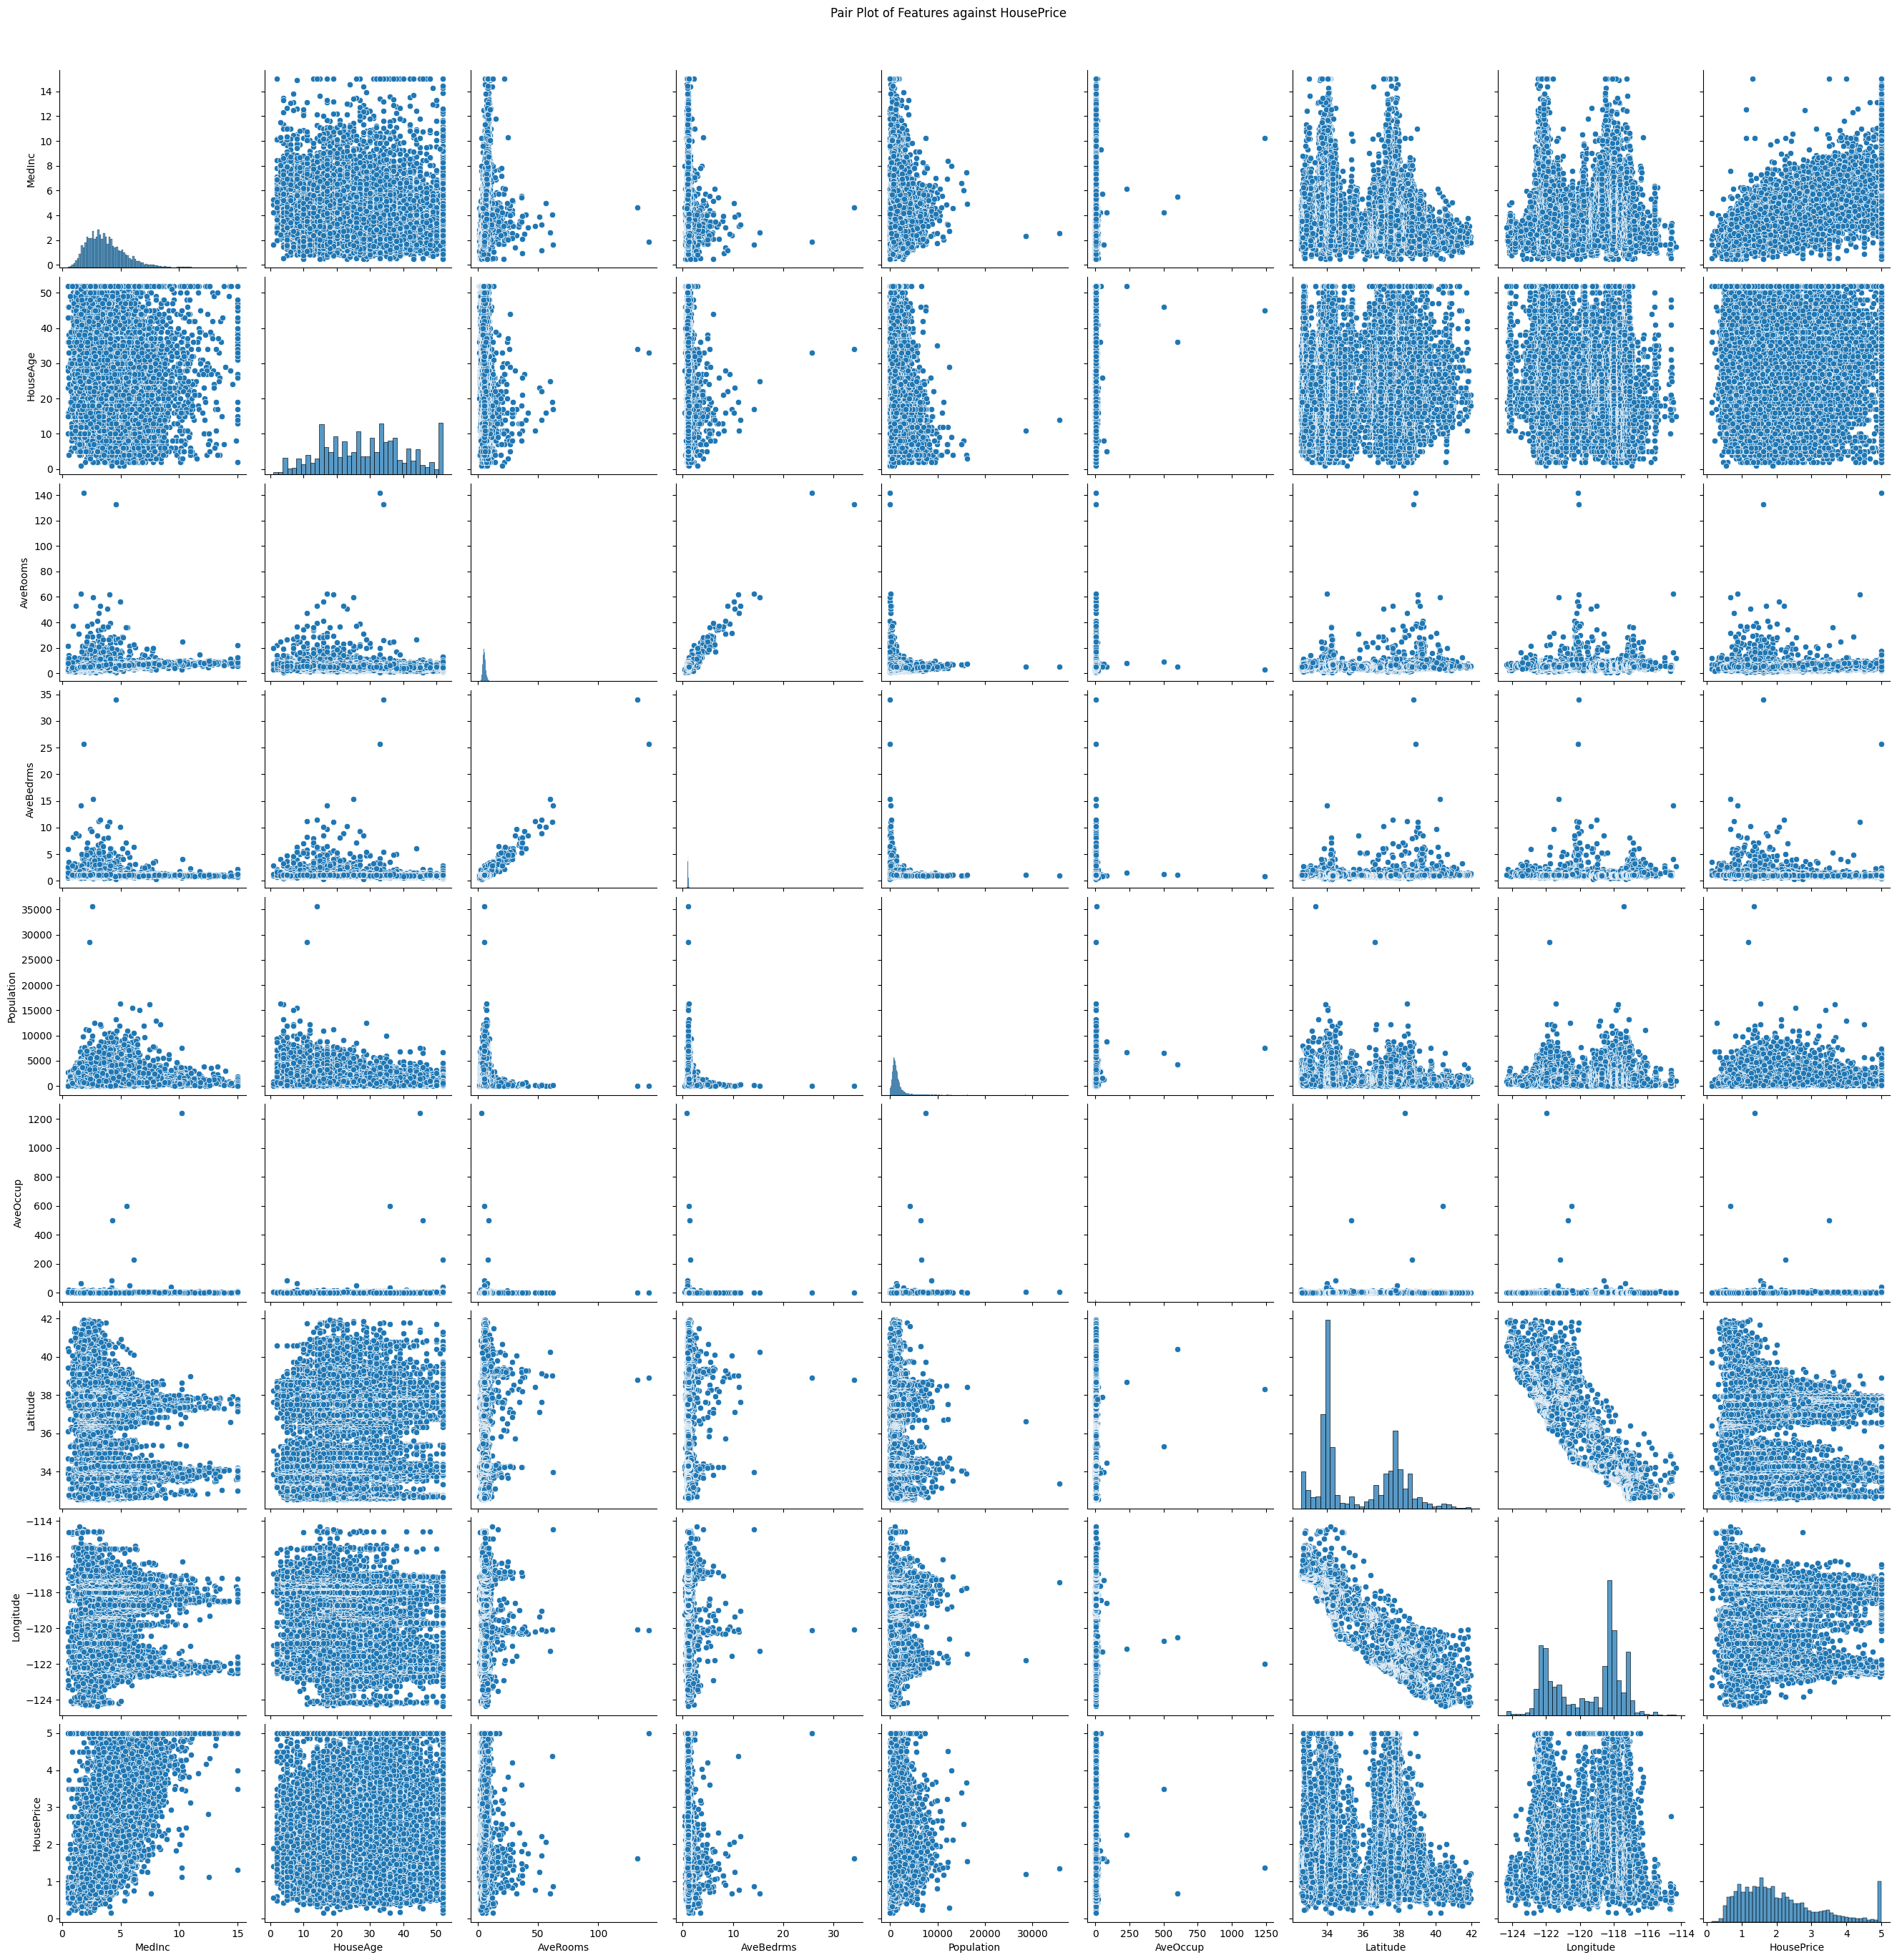

In [ ]:
sns.pairplot(housing_df, height=3) # buat grafik hubungan tiap var dengan semua var & ukuran tiap kotak grafik = 3 inch
plt.suptitle('Pair Plot of Features against HousePrice', y=1.02) # beri judul, y buat judulnya ke atas ga nutupin grafik
plt.show()

<Axes: xlabel='Longitude', ylabel='Latitude'>

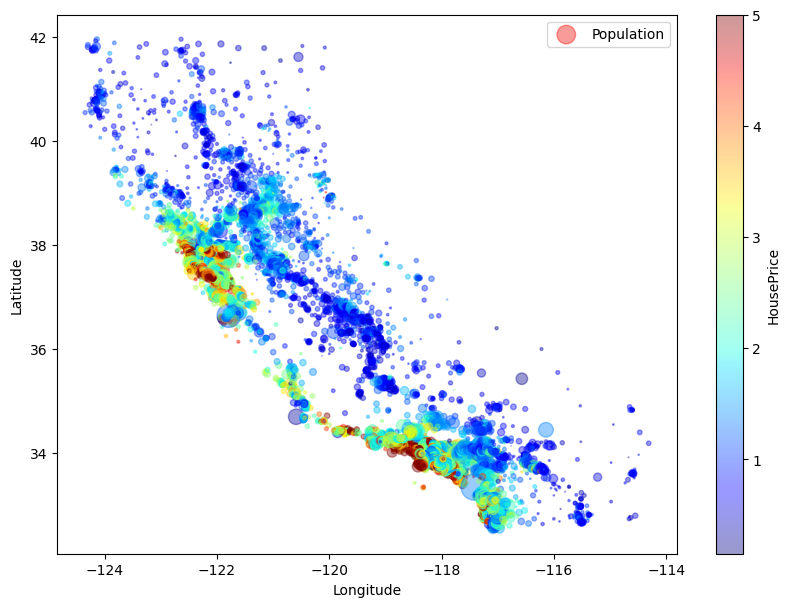

In [ ]:
# EDA (exploratory data analysis)
housing_df.plot(
    kind="scatter", # buat grafik scatter plot
    x="Longitude",# sumbu x/garis bujur (-124 - -114)
    y="Latitude", # sumbu y/garis lintang (34 - 42)
    # MAKANYA ITU BENTUK GRAFIKNYA MIIRIP NEGARA BAGIAN CALIFORNIA
    alpha=0.4,# atur transparansi titik
    s=housing_df['Population']/100, # ukuran, kalo population banyak, lingkrannnya geede
    label="Population",
    c="HousePrice", # warna ditentukan oleh HousePrice
    cmap="jet",
    colorbar=True, # yang di sebelah kanan
    figsize=(10, 7),
)

<Axes: >

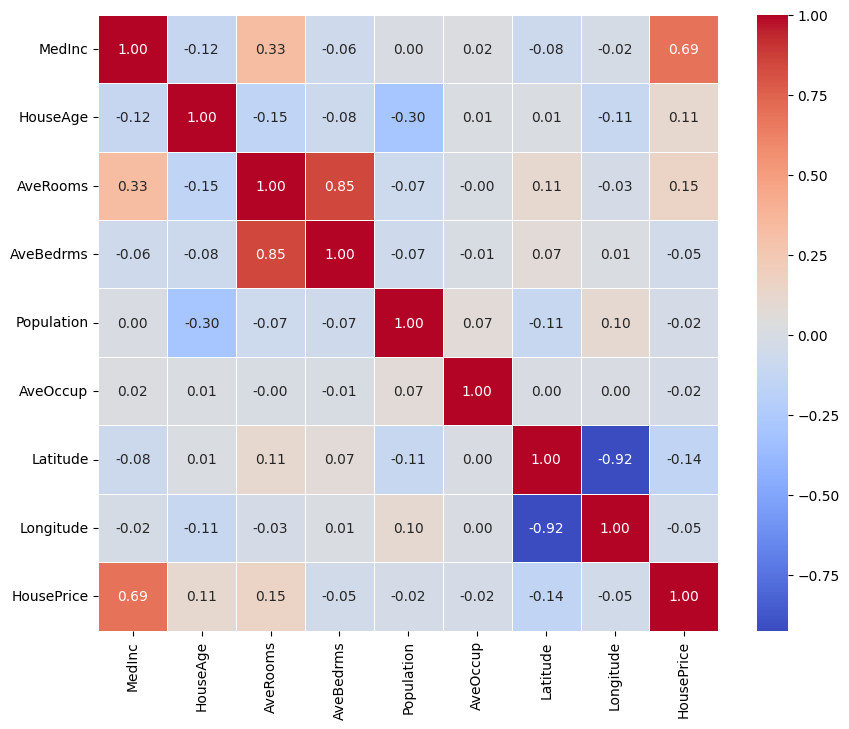

In [ ]:
# EDA pake grafik correlation heatmap
corr = housing_df.corr() # hitung koefisien korelasi pearson (metode statik ukur arah & kekuatan hub. linear 2 vars)
# 1.00 = hub. sempurna, kalo X naik, Y selalu naik; 0 = gada hubungan linear;
# -0.50 = hub. negatif sedang, X naik Y turun; -1 = hub. negatif sempurna
plt.figure(figsize=(10, 8))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidth=0.5)
# annot=True tampilin angka dalam kotak langsung, linewidth = garis antar kotak

In [ ]:
corr["HousePrice"].abs().sort_values(ascending=False) # urutin tingkat korelasi pearson (descending, gede ke kecil)

,HousePrice
HousePrice,1.000000
MedInc,0.688075
AveRooms,0.151948
Latitude,0.144160
HouseAge,0.105623
AveBedrms,0.046701
Longitude,0.045967
Population,0.024650
AveOccup,0.023737


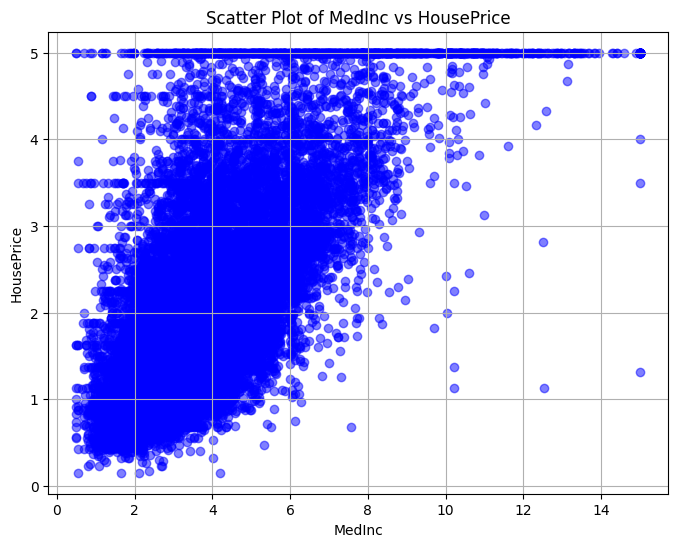

In [ ]:
# ANALISIS HUBUNGAN FITUR & MULTICOLLINEARITY

medinc = housing_df['MedInc'] # ambil kolom MedInc dan simpan ke var medinc
houseprice = housing_df['HousePrice'] # ambil target HousePrice dan simpan ke var houseprice

plt.figure(figsize=(8, 6))
plt.scatter(medinc, houseprice, alpha=0.5, color='blue')  # sumbu x = median income; sumbu y = house price (1 titik = 1 rumah)
plt.xlabel('MedInc')
plt.ylabel('HousePrice')
plt.title('Scatter Plot of MedInc vs HousePrice')
plt.grid(True)
plt.show()

# GRAFIK = MAKIN TINGGI MEDINC = MAKIN TINGGI HOUSEPRICE
# tidak buat garis lurus karna harga rumah tdk hanya dipenuhi medinc, ada lainnya, makanya ga nyebar
# atas lurus dan stop di 5 karna dataset nya punya nilai maks +/ 5 (target capping)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor # import fungsi untuk hitung VIF (ngecek antar fitur saling mirip/jelaskan)

housing_df_vif = housing_df.drop('HousePrice', axis=1) # hapus target (Y)
housing_df_vif = housing_df_vif.apply(pd.to_numeric, errors='coerce') # matikan semua kolom bertipe numerik. string --> NaN

vif_data = pd.DataFrame() # buat DataFrame
vif_data["Feature"] = housing_df_vif.columns # simpan nama fitur
vif_data["VIF"] = [variance_inflation_factor(housing_df_vif.values, i) for i in range(len(housing_df_vif.columns))]
# hitung VIF untuk tiap kolom (1 = tdk ada korelasi sampai >10 = multicollinearity parah)
print(vif_data)

      Feature         VIF
0      MedInc   11.511140
1    HouseAge    7.195917
2    AveRooms   45.993601
3   AveBedrms   43.590314
4  Population    2.935745
5    AveOccup    1.095243
6    Latitude  559.874071
7   Longitude  633.711654


In [ ]:
housing_df = housing_df.drop(['Latitude', 'Longitude'], axis=1) # hapus karna terlalu tinggi VIF nya jadi sensitif/tddk stabil modelnya atau koefisien regresi jadi berubah2 atau interpretasi model jadi sulit

In [ ]:
cols_to_convert = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
housing_df[cols_to_convert] = housing_df[cols_to_convert].apply(pd.to_numeric, errors='coerce')
housing_df['HousePrice'] = pd.to_numeric(housing_df['HousePrice'], errors='coerce')
# UBAH SEMUA KOLOM JADI TIPE NUMERIK KARNA LINEAR REGRESSION HANYA BISA HITUNG ANGKA

x = sm.add_constant(housing_df.drop('HousePrice', axis=1)) # buat var X & Y, X = semua fitur, Y = target
# add_constant bikin bingung karna kalo tdk tambahin a (y = a + bx), maka jadi (y = bx), makanya
y = housing_df['HousePrice'] # sm.add_constant tambahkan kolom 1 ke semua data

model = sm.OLS(y, x).fit() # buat Ordinary Least Squares Regression / LINEAR REGRESSION
# cari persamaan HousePrice = a + b1MedInc + b2MHouseAge + b3AveRooms + ... yang errornya paling kecil
# print(model.summary())

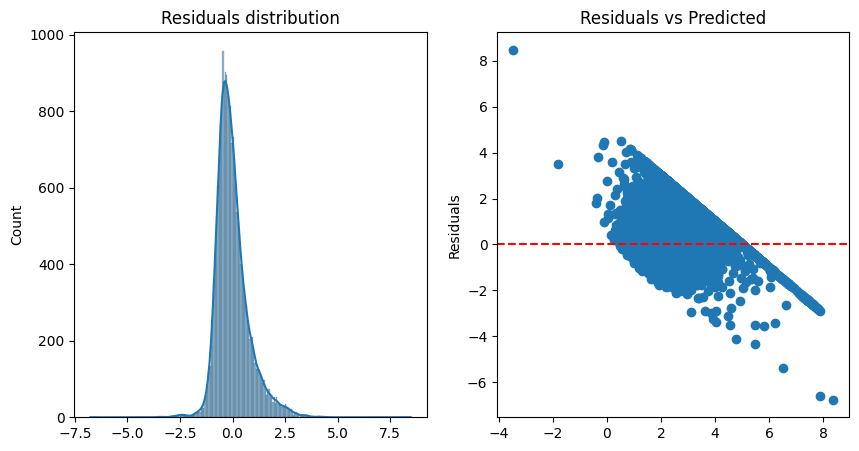

Model coefficients:
 const        -0.439093
MedInc        0.536910
HouseAge      0.016503
AveRooms     -0.211740
AveBedrms     0.993730
Population    0.000022
AveOccup     -0.004877
dtype: float64


In [ ]:
# Residual = nilai sebenernya - nilai prediksi (Residual = Y = Y^)
residuals = model.resid
# grafik 1
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
sns.histplot(residuals, kde=True) # histogram residual
plt.title('Residuals distribution')
# grafik 2
plt.subplot(1,2,2)
plt.scatter(model.predict(x), residuals) # sumbu x -> hasil prediksi model; sumbu y -> residual
plt.axhline(y=0, color='red', linestyle='--') # garis merah : residual = 0 = prediksi sempurna
# plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()

print('Model coefficients:\n', model.params) # koefisien regresi, hasil persamaan model tadi

# HASILNYA MIRING / SEGITIGA MIRING = PATTERN => RESIDUAL TDK TERSEBAR SECARA ACAK
# => heteroskedasticity = variasi residual tdk sama padahal diharapkan relatif konstan


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

predictions = model.predict(x) # model prediksi harga rumah

print("R square Score:", r2_score(y, predictions)) # seeberapa baik model jelaskan data (makin dekati 1 makin bagus)
print("MSE:", mean_squared_error(y, predictions)) # hitungan rata2 kuadrat error, dikuadratkan biar error besar lebih dihukum

R square Score: 0.5396977345638283
MSE: 0.6129156196698703


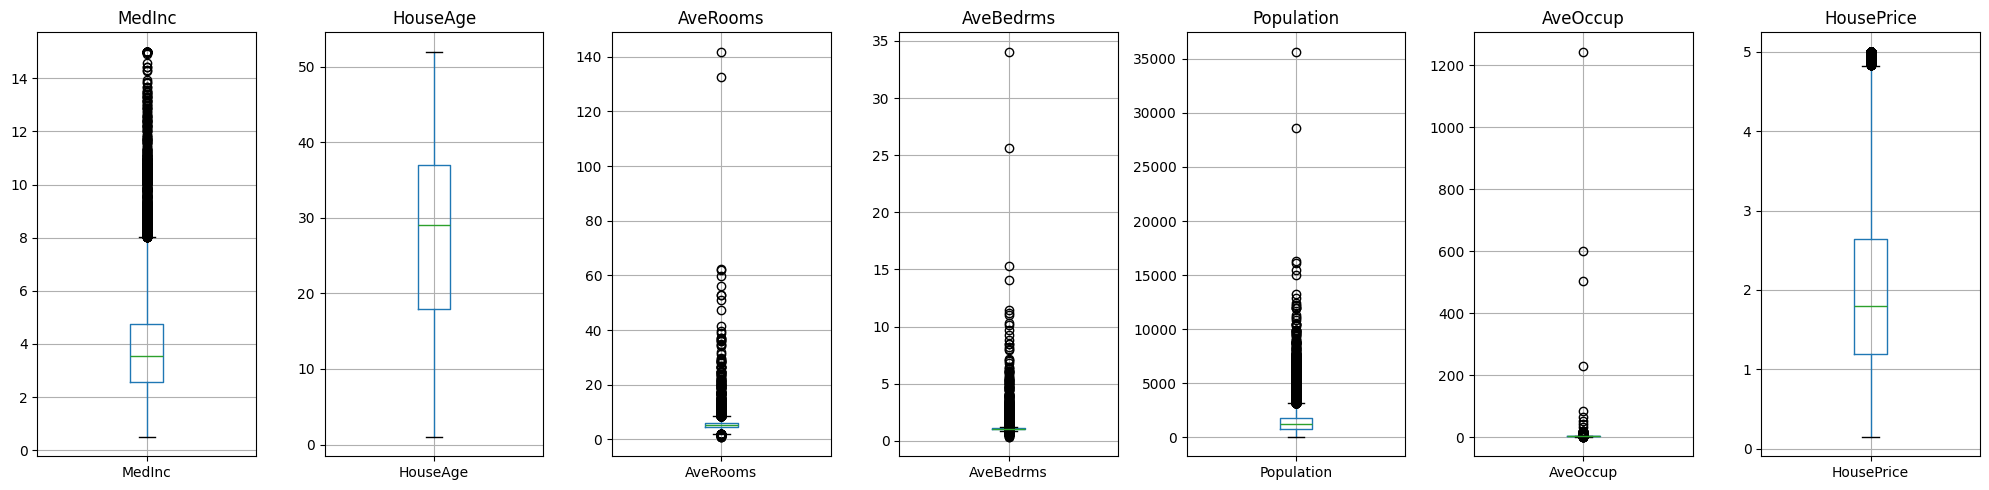

In [ ]:
import matplotlib.pyplot as plt

def plot_boxplots(df):# panggil boxplot untuk lihat persebaran data, median, kuartil, & outlier
                      # yang garis tengah itu median
                      # kotak berisi 50% data = Interquartile Range (IQR)
                      # whisker = menunjukkan batas data normal
                      # titik hitam = outlier, kalo gada = stabil
                      # kalo outlier terlalu banyak -> kadang model jadi kurang akurat

  fig, axes = plt.subplots(1, len(df.columns), figsize=(20, 5))

  for i, column_name in enumerate(df.columns):
    df.boxplot(column=column_name, ax=axes[i])
    axes[i].set_title(column_name)

  plt.tight_layout()
  plt.show()

plot_boxplots(housing_df)

In [ ]:
# PENANGANAN OUTLIER, memperbaiki (treat) outlier gunakan metode IQR (Interquartile Range)
def remove_outliers(df):  # terima DataFrame sebagai input
  df_no_outliers = df.copy() # buat salinan data pakai df.copy supaya data housing df ga berubah

  for column_name in df.columns: # program proses tiap kolom
    Q1 = df[column_name].quantile(0.25) # hitung Q1
    Q3 = df[column_name].quantile(0.75) # hitung Q3

    IQR = Q3 - Q1 # hitung IQR

    lower_bound = Q1 - 1.5 * IQR # batas bawah
    upper_bound = Q3 + 1.5 * IQR # batas atas
    # selain data di atas = outlier

    df_no_outliers[column_name] = df_no_outliers[column_name].apply(lambda x: lower_bound if x < lower_bound
                                                                    else upper_bound if x > upper_bound else x)
    # kalau x < lower_bound diubah jadi lower_bound, x > upper bound ubah jadi upper_bound = WINSORIZATION (CAPPING)

  return df_no_outliers

housing_df_new = remove_outliers(housing_df) # buat data baru yg outliernya sdh dicapping

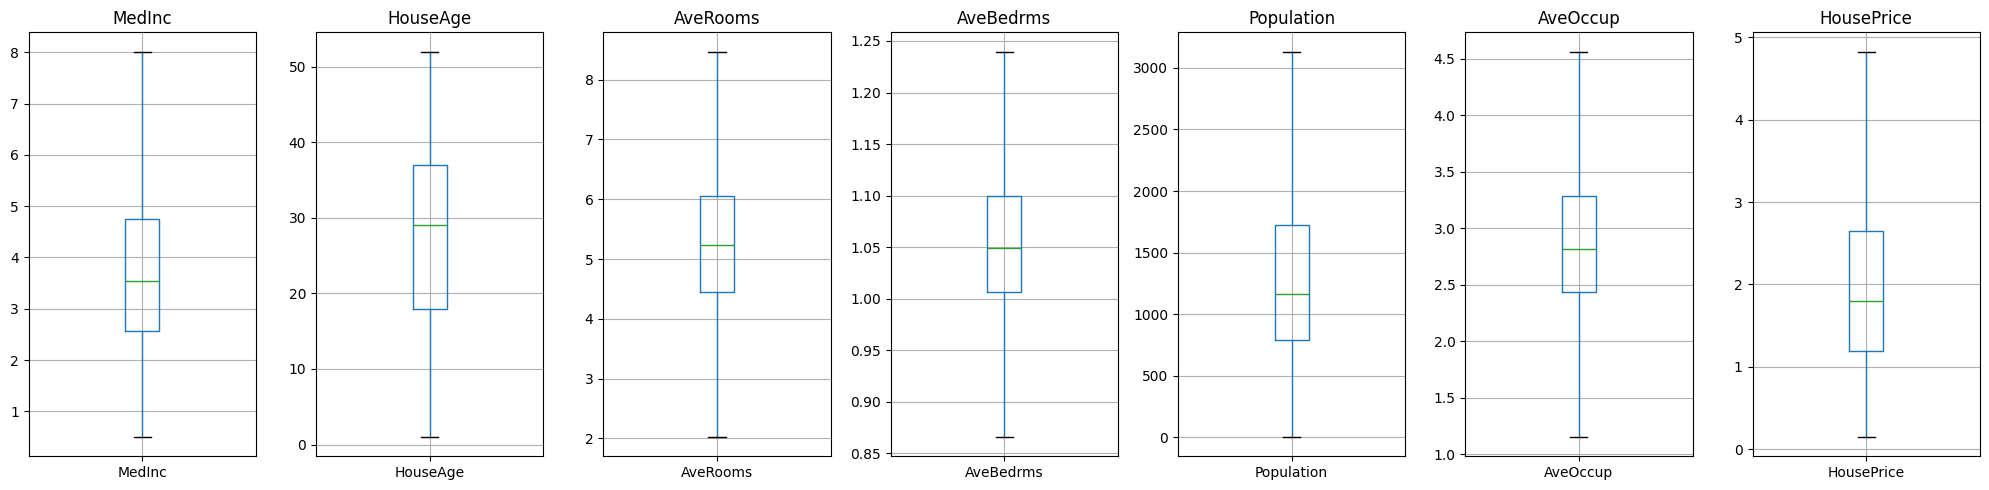

In [ ]:
plot_boxplots(housing_df_new) # udh gada titik hitam outlier karna sdh dipotong ke baatas atas/bawah

In [ ]:
cols_to_convert = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
housing_df_new[cols_to_convert] = housing_df_new[cols_to_convert].apply(pd.to_numeric, errors='coerce')
housing_df_new['HousePrice'] = pd.to_numeric(housing_df_new['HousePrice'], errors='coerce')

X = sm.add_constant(housing_df_new.drop('HousePrice', axis=1))
y = housing_df_new['HousePrice']

model = sm.OLS(y, X).fit()
# MODEL LINEAR REGRESSION DILATIH LAGI PAKAI DATA BARU ITU

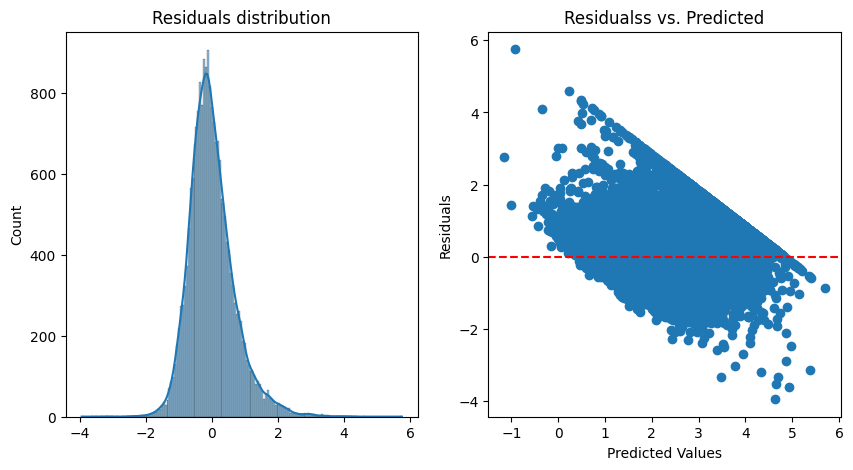

Model coefficients:
 const        -1.025744
MedInc        0.634138
HouseAge      0.018696
AveRooms     -0.258632
AveBedrms     2.308808
Population    0.000079
AveOccup     -0.357348
dtype: float64


In [ ]:
# HASIL MODEL SETELAH DILAKUKAN PENANGAN OUTLIER
residuals = model.resid

plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
sns.histplot(residuals, kde=True)
plt.title('Residuals distribution') # lebih ramping/simetris, semakin dekatin 0 = semakin bagus

plt.subplot(1,2,2)
plt.scatter(model.predict(X), residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residualss vs. Predicted')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show() # masih segitiga karna datasetnya ada karakter khusus, target maks 5 tapi model prediksi 5.5, residu jadi -0.5

print('Model coefficients:\n', model.params)

In [ ]:
# from sklearn.metrics import mean_squarred_error, r2_score

predictions = model.predict(X)

print("R square Score:", r2_score(y, predictions)) # besar variasi harga rumah dapat dijelaskan model lebi tinggi
print("MSE:", mean_squared_error(y, predictions)) # makin kecil yang artinya semakin baik

R square Score: 0.617696810976802
MSE: 0.49001892235770017
